In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [72]:
dataset = pd.read_csv('train.txt', sep=",", header=None,index_col=None)
dataset.columns = ["X1", "X2", "Y"]

In [73]:
dataset

,X1,X2,Y
0,-0.92850,-0.71995,1
1,-3.27460,2.44360,1
2,0.50871,0.64457,1
3,0.59212,-1.36930,1
4,2.14320,-2.64960,1
...,...,...,...
1045,10.90600,-7.24040,3
1046,9.95010,-8.12320,3
1047,10.70900,-7.81990,3
1048,8.44400,-9.65170,3


In [74]:
from numpy import loadtxt
Data = loadtxt("train.txt", delimiter=",", unpack=False)

In [75]:
Data

array([[-0.9285 , -0.71995,  1.     ],
       [-3.2746 ,  2.4436 ,  1.     ],
       [ 0.50871,  0.64457,  1.     ],
       ...,
       [10.709  , -7.8199 ,  3.     ],
       [ 8.444  , -9.6517 ,  3.     ],
       [12.395  , -8.21   ,  3.     ]])

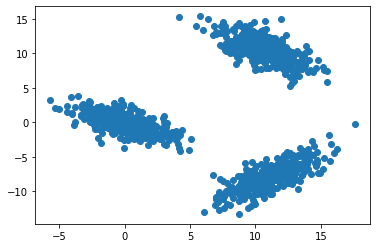

In [76]:
plt.scatter(dataset['X1'],dataset['X2'])

In [77]:
def separate_by_class(dataset):
	separated = dict()
	for i in range(len(dataset)):
		vector = dataset[i]
		class_value = vector[-1]
		if (class_value not in separated):
			separated[class_value] = list()
		separated[class_value].append(vector)
	return separated

In [78]:
Data1 = separate_by_class(Data)

In [79]:
Data1

{1.0: [array([-0.9285 , -0.71995,  1.     ]),
  array([-3.2746,  2.4436,  1.    ]),
  array([0.50871, 0.64457, 1.     ]),
  array([ 0.59212, -1.3693 ,  1.     ]),
  array([ 2.1432, -2.6496,  1.    ]),
  array([-1.4012 ,  0.73143,  1.     ]),
  array([-1.0752 , -0.94375,  1.     ]),
  array([-0.26652,  0.79366,  1.     ]),
  array([-1.5436 , -0.10377,  1.     ]),
  array([-0.93854, -1.5054 ,  1.     ]),
  array([0.30636, 1.3604 , 1.     ]),
  array([-0.91351, -0.29203,  1.     ]),
  array([0.4619 , 0.82578, 1.     ]),
  array([-2.7482 ,  0.86637,  1.     ]),
  array([-1.9228 ,  0.42743,  1.     ]),
  array([ 1.7649, -1.7965,  1.    ]),
  array([-4.4297,  2.3129,  1.    ]),
  array([-1.1589 , -0.60859,  1.     ]),
  array([-2.0733,  1.956 ,  1.    ]),
  array([-0.76247,  2.0085 ,  1.     ]),
  array([-2.4187,  1.9154,  1.    ]),
  array([ 0.080135, -2.4906  ,  1.      ]),
  array([-0.86699, -0.74075,  1.     ]),
  array([-1.6377 , -0.70615,  1.     ]),
  array([-0.50767,  0.99647,  1.   

In [80]:
meu = []
for i in Data1:
  M = []
  for j in range(len(Data1[i][0])-1):
    Data = np.asarray(Data1[i])
    M.append(np.sum(Data[:][:,j])/len(Data[:][:,j]))
  meu.append(M)

In [81]:
meu = np.asarray(meu)

In [204]:
Covarience_Matrix = []
for i in Data1:
  Data = np.asarray(Data1[i])
  Covarience_Matrix.append(np.cov(Data[:][:,0],Data[:][:,1]))


In [205]:
Covarience_Matrix = np.asarray(Covarience_Matrix)
print(Covarience_Matrix)

[[[ 4.00120544 -1.97041452]
  [-1.97041452  2.2065844 ]]

 [[ 3.4193959  -2.30650294]
  [-2.30650294  3.42358592]]

 [[ 3.81993808  2.86737734]
  [ 2.86737734  3.82415238]]]


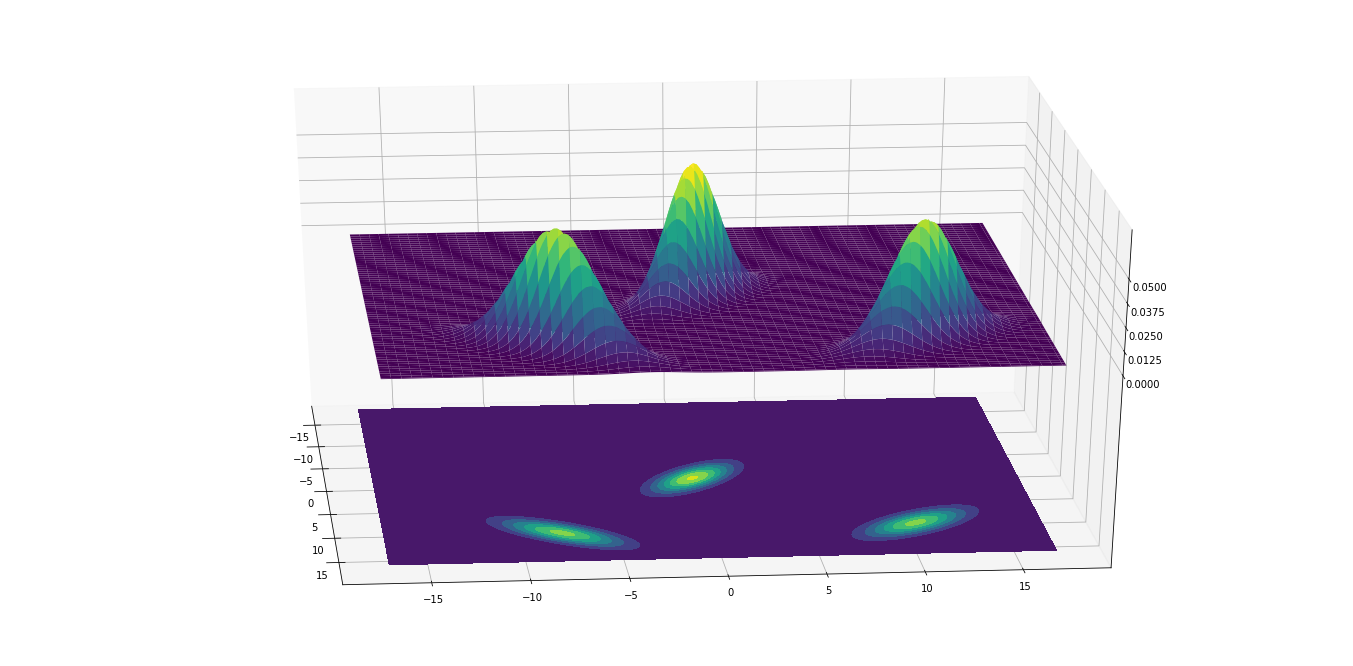

In [90]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Mean vector and covariance matrix
mu = np.asarray(meu[1])
Sigma = np.asarray(Covarience_Matrix[1])

# Our 2-dimensional distribution will be over variables X and Y
     
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos, mu, Sigma):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

    return np.exp(-fac / 2) / N

# The distribution on the variables X, Y packed into pos.
mu = np.asarray(meu[0])
Sigma = np.asarray(Covarience_Matrix[0])
Z = multivariate_gaussian(pos, mu, Sigma)
mu = np.asarray(meu[1])
Sigma = np.asarray(Covarience_Matrix[1])
Z = Z+multivariate_gaussian(pos, mu, Sigma)
mu = np.asarray(meu[2])
Sigma = np.asarray(Covarience_Matrix[2])
Z = Z+multivariate_gaussian(pos, mu, Sigma)
# Create a surface plot and projected filled contour plot under it.
fig = plt.figure(figsize=(24,12))
ax = fig.gca(projection='3d')
ax.plot_surface(X, Y, Z, rstride=3, cstride=3, linewidth=1, antialiased=True,
                cmap=cm.viridis)
cset = ax.contourf(X, Y, Z, zdir='z', offset=-0.1, cmap=cm.viridis)

# Adjust the limits, ticks and view angle
ax.set_zlim(-0.1,np.max(Z))
ax.set_zticks(np.linspace(0,0.05,5))
ax.view_init(27,-5)

plt.show()

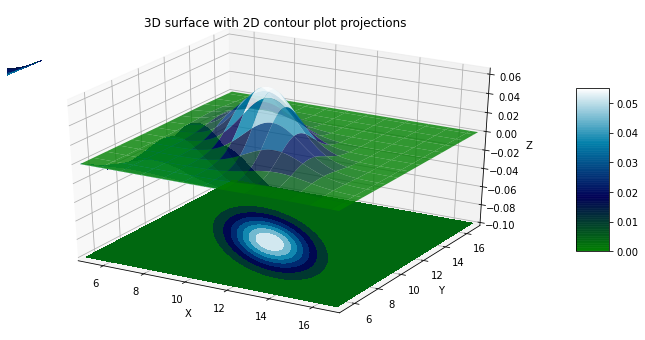

In [85]:
mu = np.asarray(meu[1])
Sigma = np.asarray(Covarience_Matrix[1])

# Our 2-dimensional distribution will be over variables X and Y

sigma_1, sigma_2 = Covarience_Matrix[1][0,0], Covarience_Matrix[1][1,1]
     
X = np.linspace(5,17 , num=100)
Y = np.linspace(5, 17, num=100)
X, Y = np.meshgrid(X, Y)

# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y

def multivariate_gaussian(pos, mu, Sigma):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

    return np.exp(-fac / 2) / N

# The distribution on the variables X, Y packed into pos.
Z = multivariate_gaussian(pos, mu, Sigma)
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111, projection='3d')


surf = ax.plot_surface(X, Y, Z, rstride=8, cstride=8, alpha=0.8, cmap=cm.ocean)
cset = ax.contourf(X, Y, Z, zdir='z', offset=-0.1, cmap=cm.ocean)
cset = ax.contourf(X, Y, Z, zdir='x', offset=-5,cmap=cm.ocean)
cset = ax.contourf(X, Y, Z, zdir='y', offset=5, cmap=cm.ocean)


fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)


ax.set_xlabel('X')
ax.set_xlim(5, 17)
ax.set_ylabel('Y')
ax.set_ylim(5, 17)
ax.set_zlabel('Z')
ax.set_zlim(-0.1, np.max(Z))
ax.set_title('3D surface with 2D contour plot projections')


plt.show()

Assumption Every Class has equal Covariance matrix (Covariance matrix of class1)
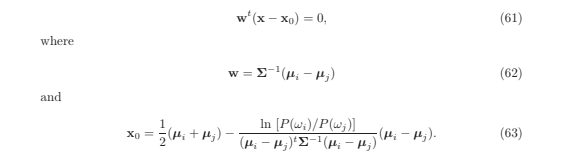

In [91]:
W = np.linalg.inv(Covarience_Matrix[1])@(meu[0]-meu[1])
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)
print(W)


[-9.50800999 -9.51957662]


In [92]:
X1 = np.linspace(-17,17 , num=200)
Eqn12 = -9.50800999*(X1)/9.51957662+9.50800999*(meu[0][0]+meu[1][0])/(2*9.51957662)+(meu[0][1]+meu[1][1])/2

In [93]:
Eqn12 

array([27.54160278, 27.3709561 , 27.20030943, 27.02966275, 26.85901607,
       26.68836939, 26.51772272, 26.34707604, 26.17642936, 26.00578268,
       25.83513601, 25.66448933, 25.49384265, 25.32319598, 25.1525493 ,
       24.98190262, 24.81125594, 24.64060927, 24.46996259, 24.29931591,
       24.12866923, 23.95802256, 23.78737588, 23.6167292 , 23.44608253,
       23.27543585, 23.10478917, 22.93414249, 22.76349582, 22.59284914,
       22.42220246, 22.25155579, 22.08090911, 21.91026243, 21.73961575,
       21.56896908, 21.3983224 , 21.22767572, 21.05702904, 20.88638237,
       20.71573569, 20.54508901, 20.37444234, 20.20379566, 20.03314898,
       19.8625023 , 19.69185563, 19.52120895, 19.35056227, 19.1799156 ,
       19.00926892, 18.83862224, 18.66797556, 18.49732889, 18.32668221,
       18.15603553, 17.98538885, 17.81474218, 17.6440955 , 17.47344882,
       17.30280215, 17.13215547, 16.96150879, 16.79086211, 16.62021544,
       16.44956876, 16.27892208, 16.1082754 , 15.93762873, 15.76

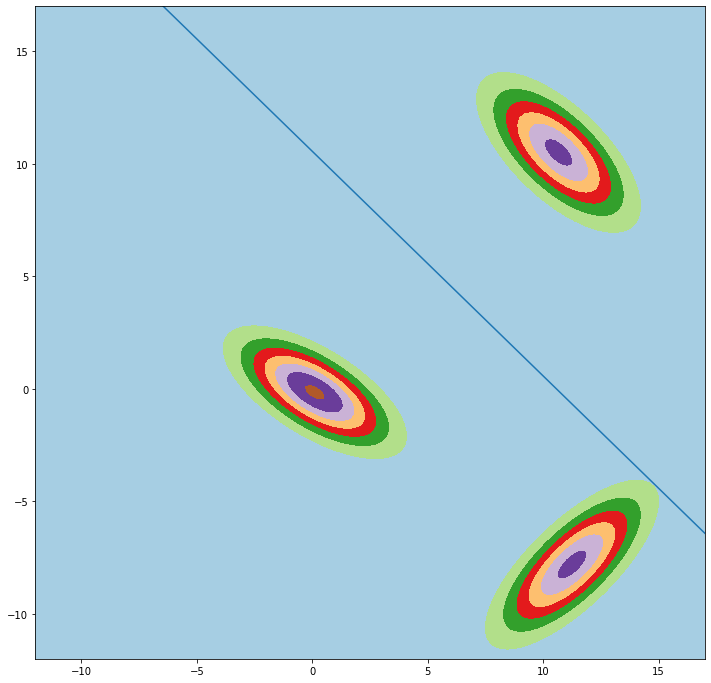

In [94]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn12)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [95]:
W = np.linalg.inv(Covarience_Matrix[1])@(meu[0]-meu[2])
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)
print(W)


[-3.20168596  0.08207784]


In [96]:

Eqn13 = 3.20168596*(X1)/0.08207784-3.20168596*(meu[0][0]+meu[2][0])/(2*0.08207784)+(meu[0][1]+meu[2][1])/2

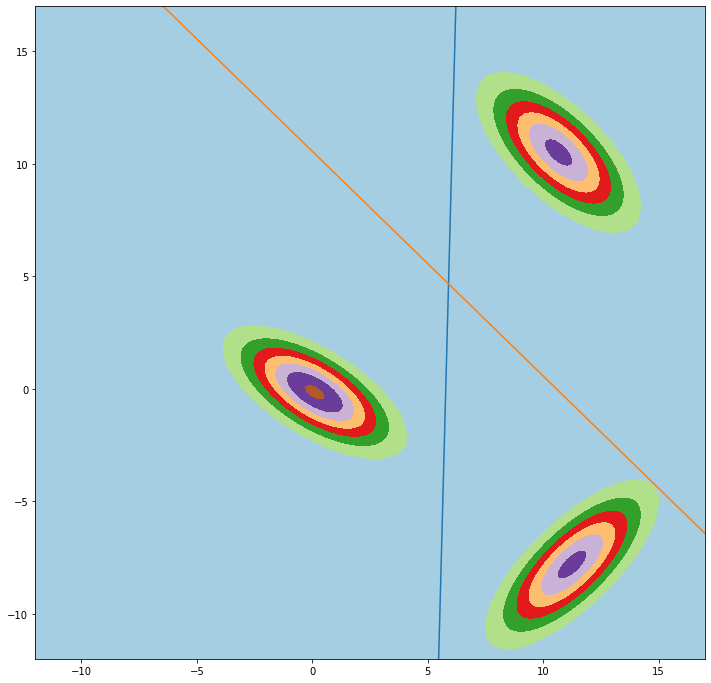

In [97]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn13)
plt.plot(X1,Eqn12)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [98]:
W = np.linalg.inv(Covarience_Matrix[1])@(meu[1]-meu[2])
X = np.linspace(-17,17 , num=200)
Y = np.linspace(-17, 17, num=200)
X, Y = np.meshgrid(X, Y)
print(W)

[6.30632403 9.60165445]


In [99]:
Eqn23 = -6.30632403*(X1)/9.60165445+6.30632403*(meu[1][0]+meu[2][0])/(2*9.60165445)+(meu[1][1]+meu[2][1])/2

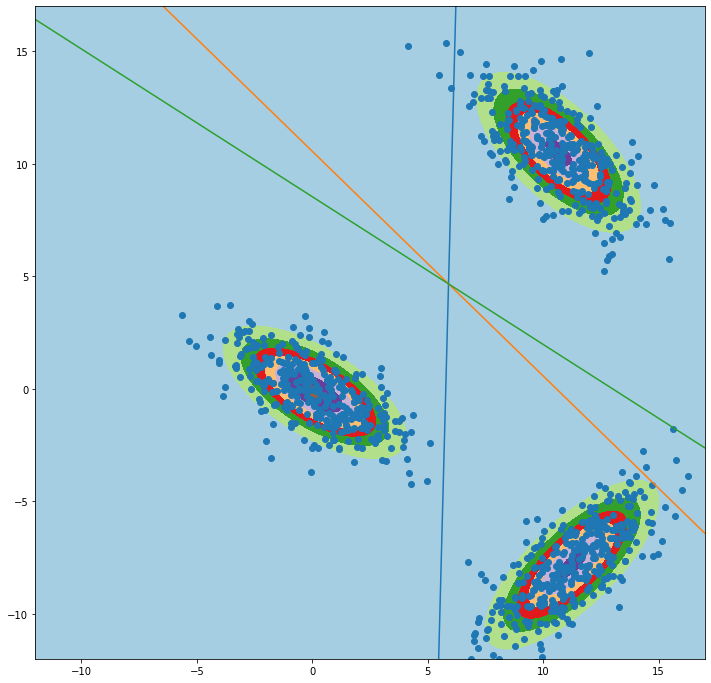

In [100]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn13)
plt.ylim([-10, 5])
plt.plot(X1,Eqn12)
plt.plot(X1,Eqn23)
plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [101]:
idx = np.argwhere(np.diff(np.sign(Eqn12 - Eqn13))).flatten()
idx

array([134])

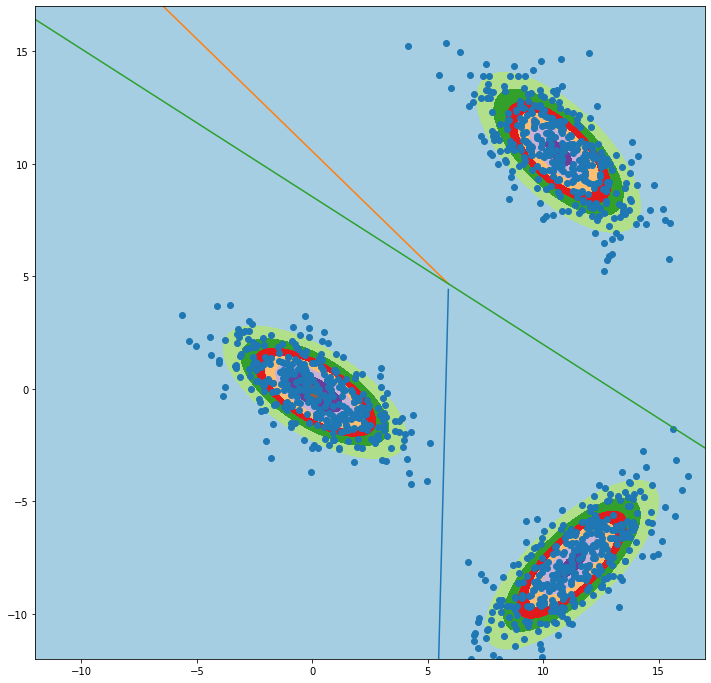

In [102]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[:135],Eqn13[:135])
plt.ylim([-10, 5])
plt.plot(X1[:135],Eqn12[:135])
plt.plot(X1,Eqn23)
plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [103]:
idx = np.argwhere(np.diff(np.sign(Eqn23 - Eqn13))).flatten()
idx

array([134])

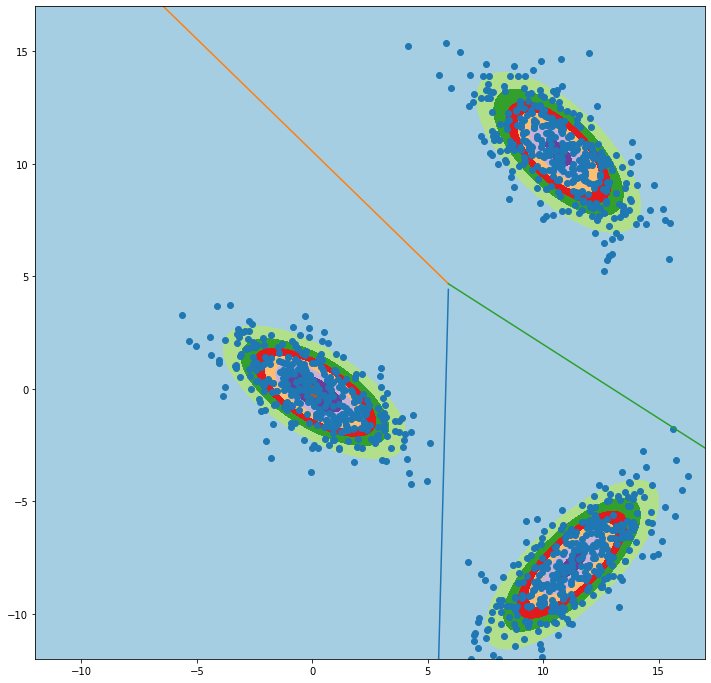

In [104]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[:135],Eqn13[:135])
plt.ylim([-10, 5])
plt.plot(X1[:135],Eqn12[:135])
plt.plot(X1[134:],Eqn23[134:])
plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

Case 2

In [206]:
Covarience_Matrix

array([[[ 4.00120544, -1.97041452],
        [-1.97041452,  2.2065844 ]],

       [[ 3.4193959 , -2.30650294],
        [-2.30650294,  3.42358592]],

       [[ 3.81993808,  2.86737734],
        [ 2.86737734,  3.82415238]]])

In [207]:
w1 = (np.linalg.inv(Covarience_Matrix[0])@meu[0]-np.linalg.inv(Covarience_Matrix[1])@meu[1])
w01 = -0.5*(meu[0].T@np.linalg.inv(Covarience_Matrix[0])@meu[0]-meu[1].T@np.linalg.inv(Covarience_Matrix[1])@meu[1])-0.5*np.log(np.abs(np.linalg.det(Covarience_Matrix[0])/np.linalg.det(Covarience_Matrix[1])))
W1 = -0.5*(np.linalg.inv(Covarience_Matrix[0])-np.linalg.inv(Covarience_Matrix[1]))
print(w1,w01,W1)

[-9.5235114  -9.55634672] 100.674104075311 [[ 0.04498052 -0.01860155]
 [-0.01860155 -0.13675194]]


In [107]:
Eqn212 = 0.04498052*X**2 - 0.13675194*Y**2 - 2*0.01860155*X*Y - 9.5235114*X - 9.55634672*Y + 100.418568796071

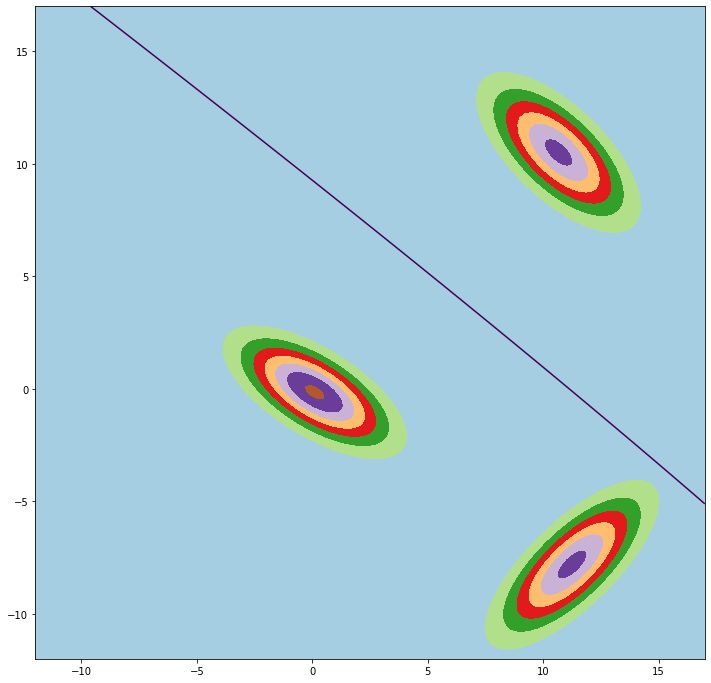

In [108]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn212,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [208]:
w1 = (np.linalg.inv(Covarience_Matrix[0])@meu[0]-np.linalg.inv(Covarience_Matrix[2])@meu[2])
w01 = -0.5*(meu[0].T@np.linalg.inv(Covarience_Matrix[0])@meu[0]-meu[2].T@np.linalg.inv(Covarience_Matrix[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(Covarience_Matrix[0])/np.linalg.det(Covarience_Matrix[2])))
W1 = -0.5*(np.linalg.inv(Covarience_Matrix[0])-np.linalg.inv(Covarience_Matrix[2]))
print(w1,w01,W1)

[-10.25452964   9.64798043] 95.7353220895401 [[ 0.07636215 -0.42367294]
 [-0.42367294 -0.10537224]]


In [211]:
Eqn213 = 0.07636215*X**2 - 0.10537224*Y**2 - 2*0.42367294*X*Y - 10.25452964*X + 9.64798043*Y + 95.7353220895401

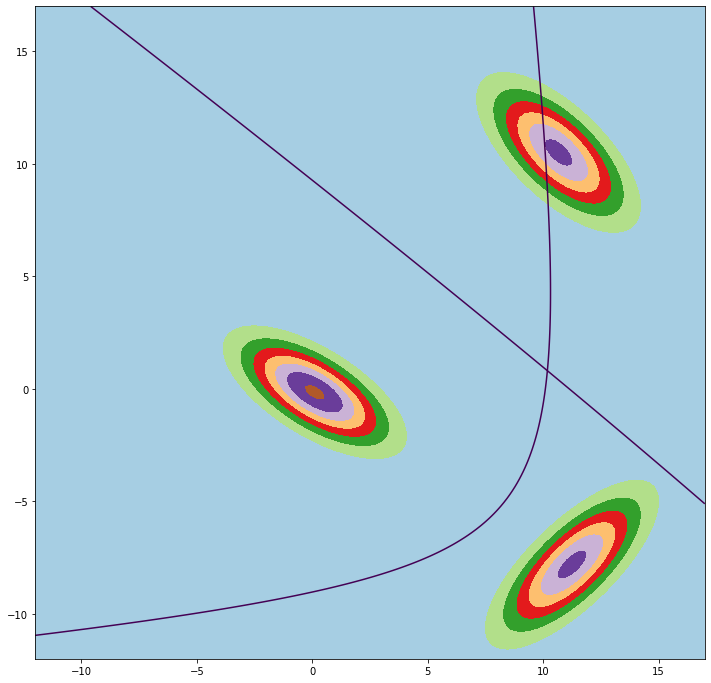

In [212]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn212,[0])
plt.contour(X, Y, Eqn213,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [213]:
w1 = (np.linalg.inv(Covarience_Matrix[1])@meu[1]-np.linalg.inv(Covarience_Matrix[2])@meu[2])
w01 = -0.5*(meu[1].T@np.linalg.inv(Covarience_Matrix[1])@meu[1]-meu[2].T@np.linalg.inv(Covarience_Matrix[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(Covarience_Matrix[1])/np.linalg.det(Covarience_Matrix[2])))
W1 = -0.5*(np.linalg.inv(Covarience_Matrix[1])-np.linalg.inv(Covarience_Matrix[2]))
print(w1,w01,W1)

[-0.73101824 19.20432715] -4.938781985770907 [[ 0.03138163 -0.40507139]
 [-0.40507139  0.0313797 ]]


In [214]:
Eqn223 = 0.03138163*X**2 + 0.0313797*Y**2 - 2*0.40507139*X*Y - 0.73101824*X + 19.20432715*Y - 4.938781985770907

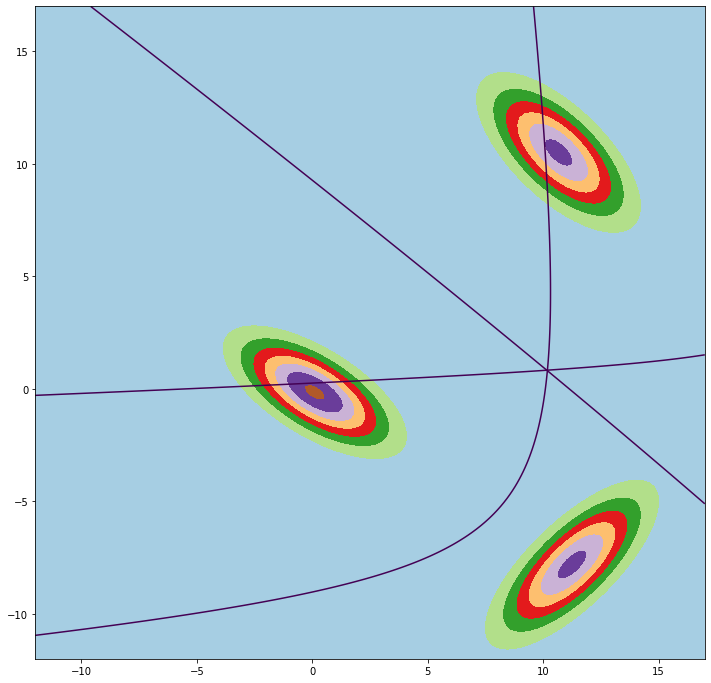

In [215]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn212,[0])
plt.contour(X, Y, Eqn213,[0])
plt.contour(X, Y, Eqn223,[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [225]:
idx = np.argwhere(np.diff(np.sign(Eqn213[:,:50] - Eqn223[:,:50]))).flatten()
idx

array([195,  48, 196,  47, 197,  46, 198,  44, 199,  43])

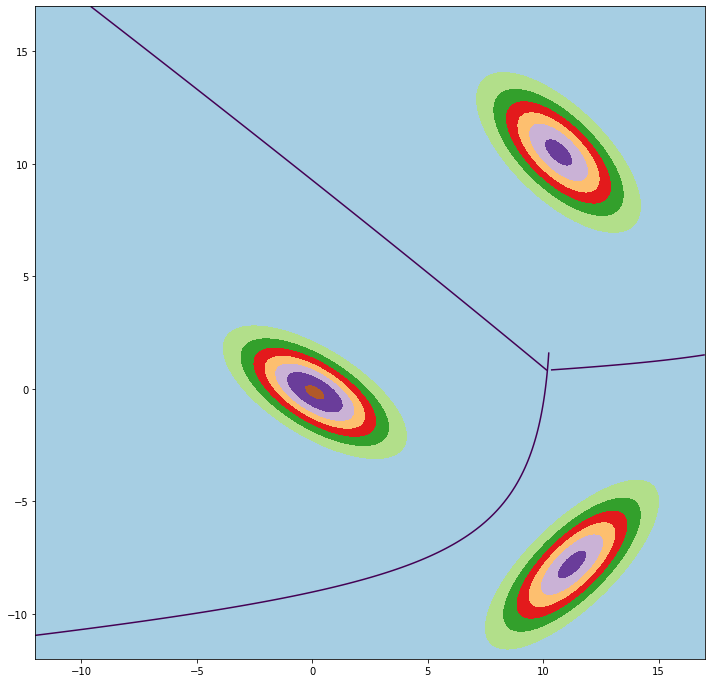

In [235]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X[:,:160], Y[:,:160], Eqn212[:,:160],[0])
plt.contour(X[:110], Y[:110], Eqn213[:110],[0])
plt.contour(X[:,160:], Y[:,160:], Eqn223[:,160:],[0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

**Case3**
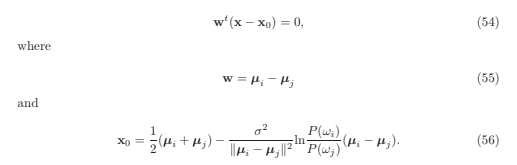

In [109]:
W31 = meu[0] - meu[1]
W31

array([-10.55471891, -10.66083542])

In [110]:
Eqn312 = -10.55471891*(X1)/10.66083542+10.55471891*(meu[0][0]+meu[1][0])/(2*10.66083542)+(meu[0][1]+meu[1][1])/2

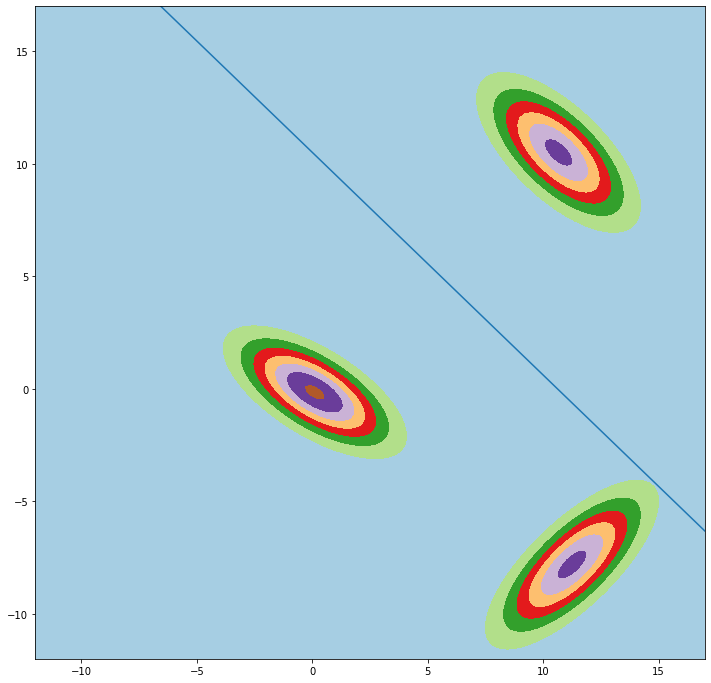

In [111]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn312)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [112]:
W32 = meu[0] - meu[2]
W32

array([-11.13714462,   7.66569861])

In [113]:
Eqn313 = 11.13714462*(X1)/7.66569861 - 11.13714462*(meu[0][0]+meu[2][0])/(2*7.66569861)+(meu[0][1]+meu[2][1])/2

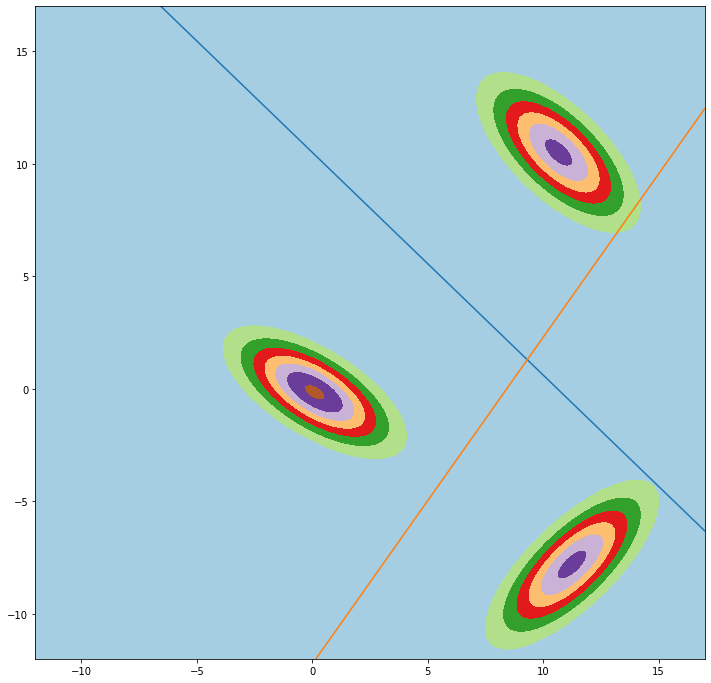

In [114]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn312)
plt.plot(X1,Eqn313)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [115]:
W33 = meu[1] - meu[2]
W33

array([-0.58242571, 18.32653403])

In [116]:
Eqn323 = -0.58242571*(X1)/18.32653403 + 0.58242571*(meu[1][0]+meu[2][0])/(2*18.32653403)+(meu[1][1]+meu[2][1])/2

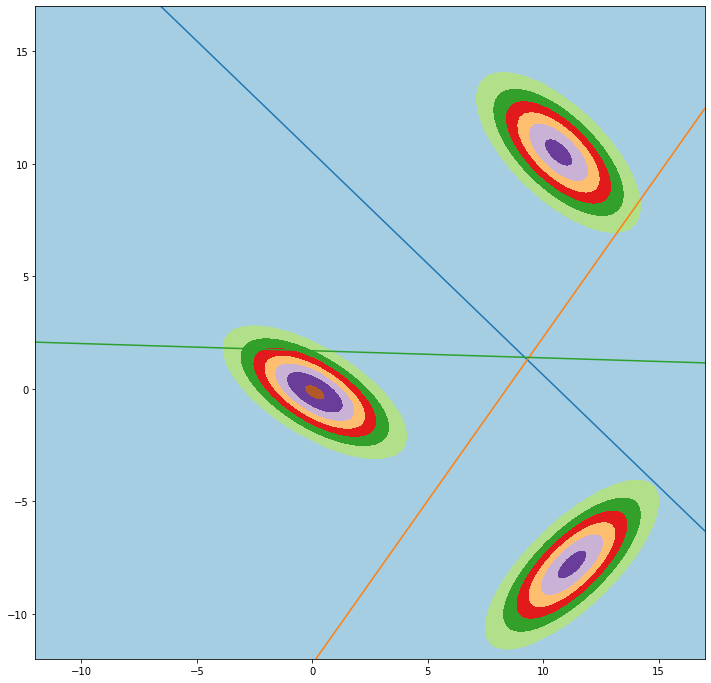

In [117]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn312)
plt.plot(X1,Eqn313)
plt.plot(X1,Eqn323)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [118]:
idx = np.argwhere(np.diff(np.sign(Eqn312 - Eqn313))).flatten()
idx

array([154])

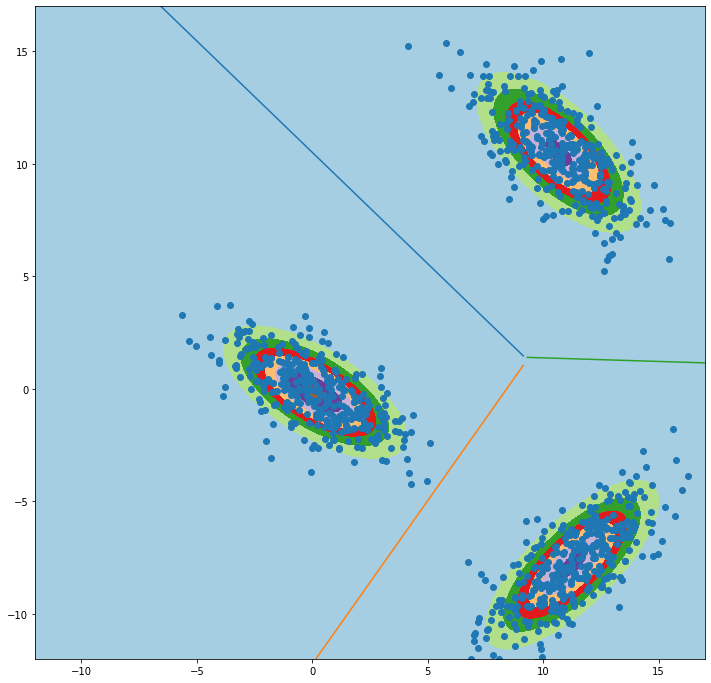

In [119]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[:154],Eqn312[:154])
plt.plot(X1[:154],Eqn313[:154])
plt.plot(X1[154:],Eqn323[154:])
plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

Case 4 Diagonal Covariance Matrix of Class1
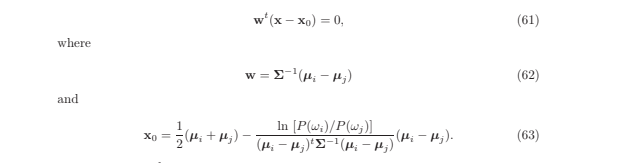

In [120]:
cov = Covarience_Matrix[1]
cov[0][1]=0
cov[1][0]=0
W4 = np.linalg.inv(cov)@(meu[0]-meu[1])

print(W4)


[-3.08672035 -3.11393833]


In [121]:
Eqn412 = -3.08672035*(X1)/3.11393833+3.08672035*(meu[0][0]+meu[1][0])/(2*3.11393833)+(meu[0][1]+meu[1][1])/2

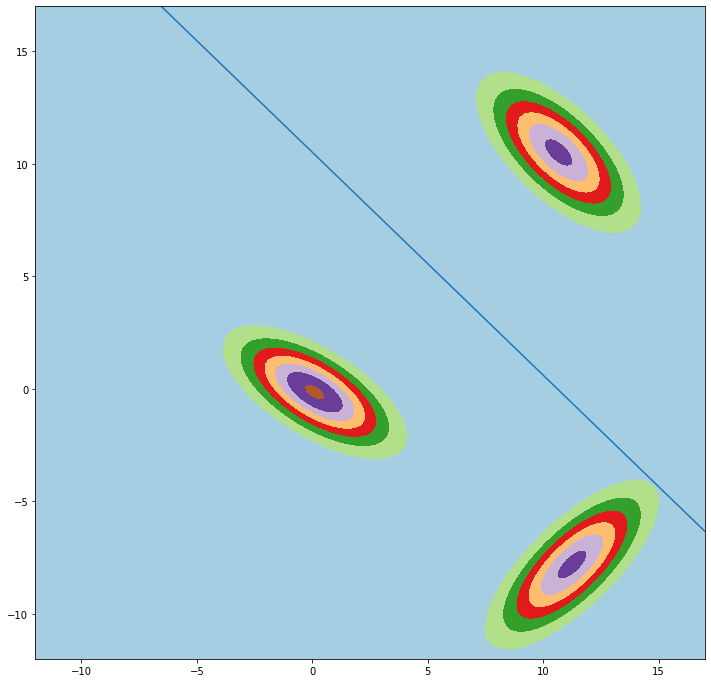

In [122]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn412)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [123]:
W4 = np.linalg.inv(cov)@(meu[0]-meu[2])
print(W4)


[-3.25705035  2.23908463]


In [124]:
Eqn413 = 3.25705035*(X1)/2.23908463-3.25705035*(meu[0][0]+meu[2][0])/(2*2.23908463)+(meu[0][1]+meu[2][1])/2

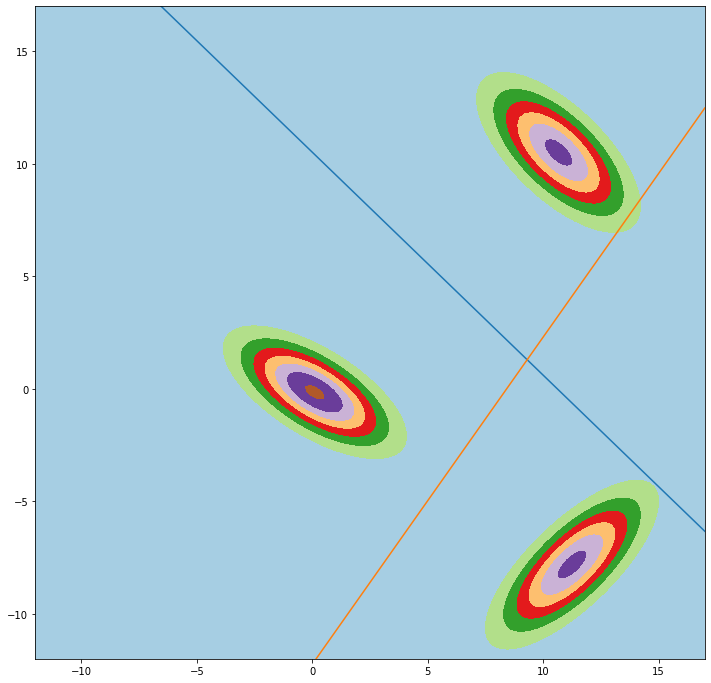

In [125]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn412)
plt.plot(X1,Eqn413)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [126]:
W4 = np.linalg.inv(cov)@(meu[1]-meu[2])
print(W4)

[-0.17033     5.35302296]


In [127]:
Eqn423 = 0.17033*(X1)/5.35302296-0.17033*(meu[1][0]+meu[2][0])/(2*5.35302296)+(meu[1][1]+meu[2][1])/2

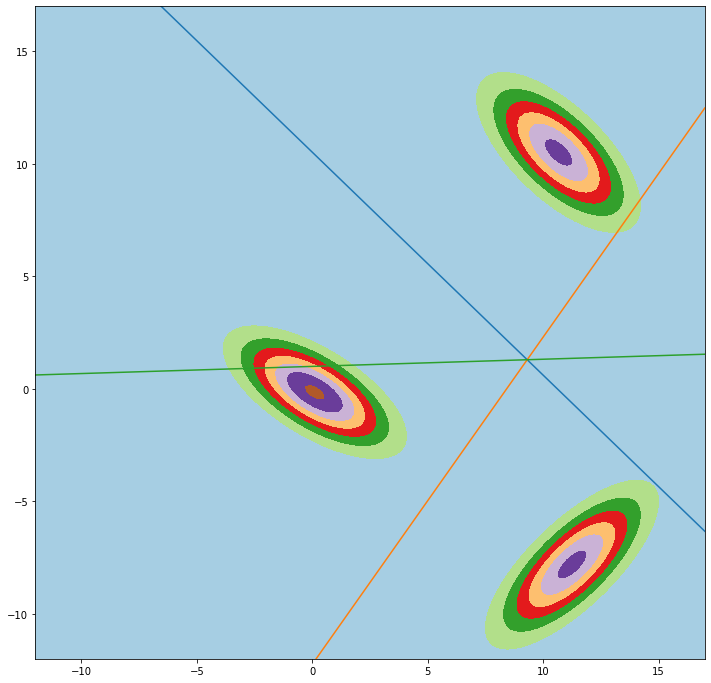

In [128]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1,Eqn412)
plt.plot(X1,Eqn413)
plt.plot(X1,Eqn423)
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [129]:
idx = np.argwhere(np.diff(np.sign(Eqn312 - Eqn313))).flatten()
idx

array([154])

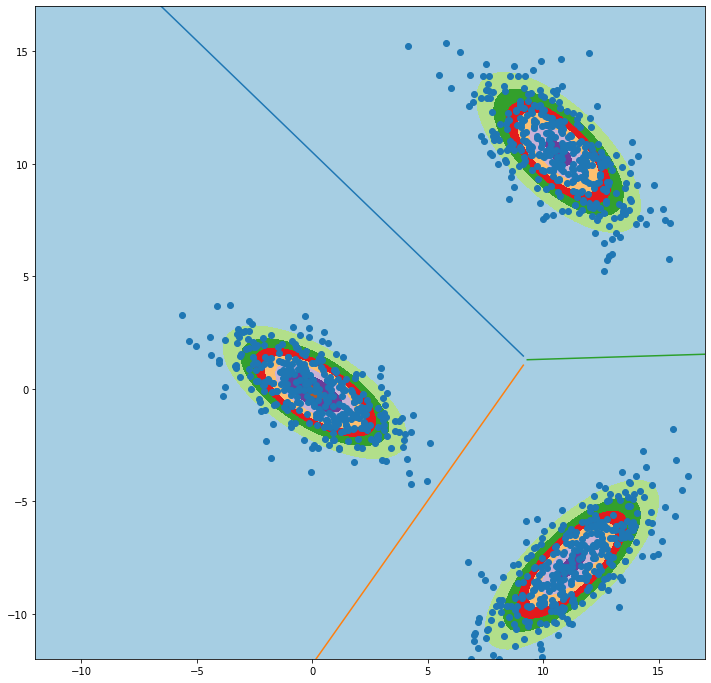

In [130]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.plot(X1[:154],Eqn412[:154])
plt.plot(X1[:154],Eqn413[:154])
plt.plot(X1[154:],Eqn423[154:])
plt.scatter(dataset['X1'],dataset['X2'])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

Case 5
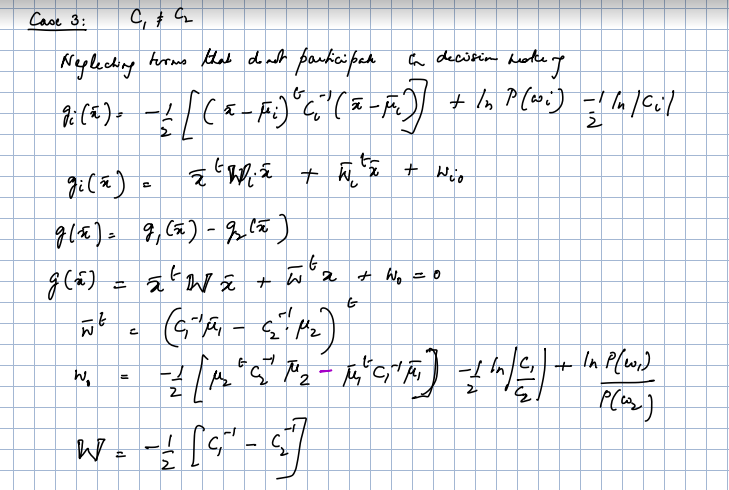

In [131]:
cov = Covarience_Matrix
cov[0][0][1]=0 
cov[0][1][0]=0
cov[1][0][1]=0 
cov[1][1][0]=0
cov[2][0][1]=0 
cov[2][1][0]=0
cov

array([[[4.00120544, 0.        ],
        [0.        , 2.2065844 ]],

       [[3.4193959 , 0.        ],
        [0.        , 3.42358592]],

       [[3.81993808, 0.        ],
        [0.        , 3.82415238]]])

In [132]:
w = (np.linalg.inv(cov[0])@meu[0]-np.linalg.inv(cov[1])@meu[1])
w0 = -0.5*(meu[0].T@np.linalg.inv(cov[0])@meu[0]-meu[1].T@np.linalg.inv(cov[1])@meu[1])-0.5*np.log(np.abs(np.linalg.det(cov[0])/np.linalg.det(cov[1])))
W = -0.5*(np.linalg.inv(cov[0])-np.linalg.inv(cov[1]))
print(w,w0,W)

[-3.09141928 -3.13801783] 32.903475328046 [[ 0.02126232 -0.        ]
 [-0.         -0.08054885]]


In [133]:
Eqn512 = 0.02126232*X**2 - 0.08054885*Y**2 - 3.09141928*X - 3.13801783*Y + 32.903475328046

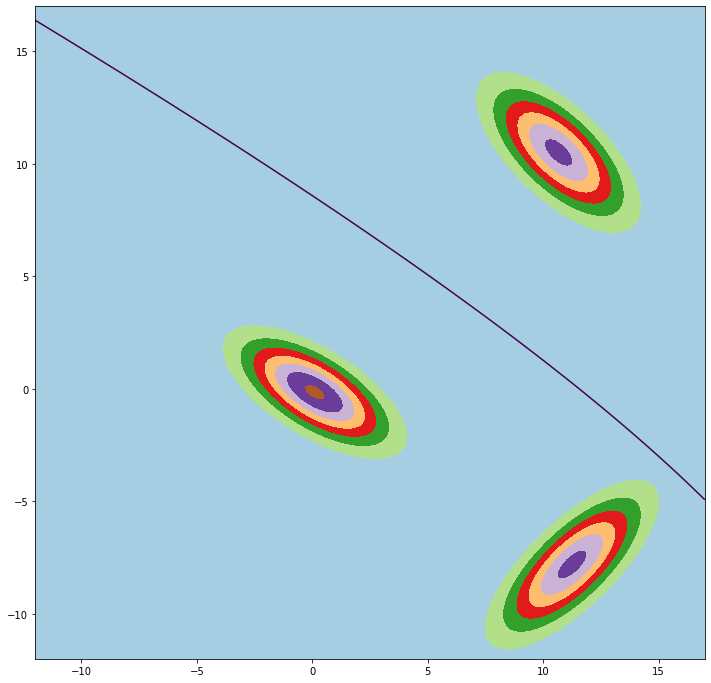

In [134]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn512, [0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [135]:
w = (np.linalg.inv(cov[0])@meu[0]-np.linalg.inv(cov[2])@meu[2])
w0 = -0.5*(meu[0].T@np.linalg.inv(cov[0])@meu[0]-meu[2].T@np.linalg.inv(cov[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(cov[0])/np.linalg.det(cov[2])))
W = -0.5*(np.linalg.inv(cov[0])-np.linalg.inv(cov[2]))
print(w,w0,W)

[-2.91684063  1.97589576] 24.789954386131182 [[ 0.00592983 -0.        ]
 [-0.         -0.09584662]]


In [136]:
Eqn513 = 0.00592983*X**2 - 0.09584662*Y**2 - 2.91684063*X + 1.97589576*Y + 24.789954386131182

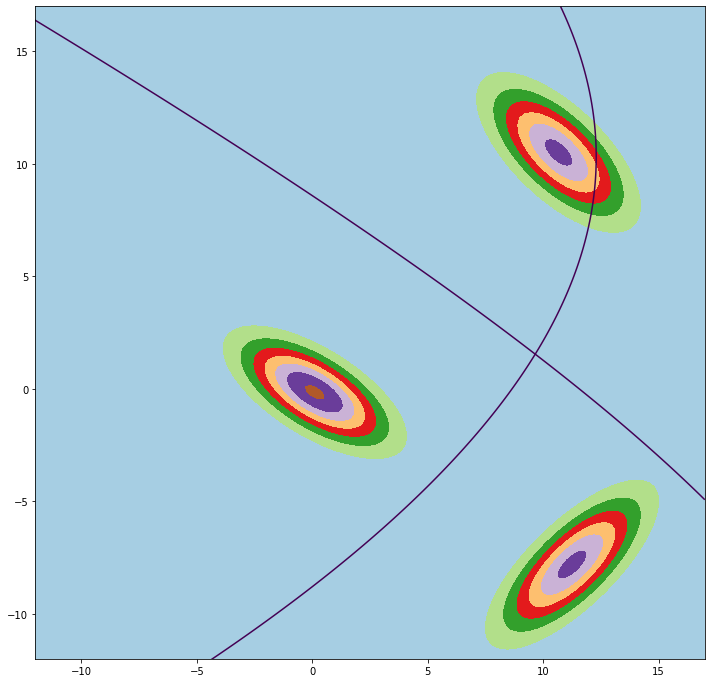

In [137]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X, Y, Eqn512, [0])
plt.contour(X, Y, Eqn513, [0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [138]:
w = (np.linalg.inv(cov[1])@meu[1]-np.linalg.inv(cov[2])@meu[2])
w0 = -0.5*(meu[1].T@np.linalg.inv(cov[1])@meu[1]-meu[2].T@np.linalg.inv(cov[2])@meu[2])-0.5*np.log(np.abs(np.linalg.det(cov[1])/np.linalg.det(cov[2])))
W = -0.5*(np.linalg.inv(cov[1])-np.linalg.inv(cov[2]))
print(w,w0,W)

[0.17457865 5.11391359] -8.113520941914818 [[-0.01533248 -0.        ]
 [-0.         -0.01529777]]


In [139]:
Eqn523 = -0.01533248*X**2 - 0.01529777*Y**2 + 0.17457865*X + 5.11391359*Y - 8.113520941914818

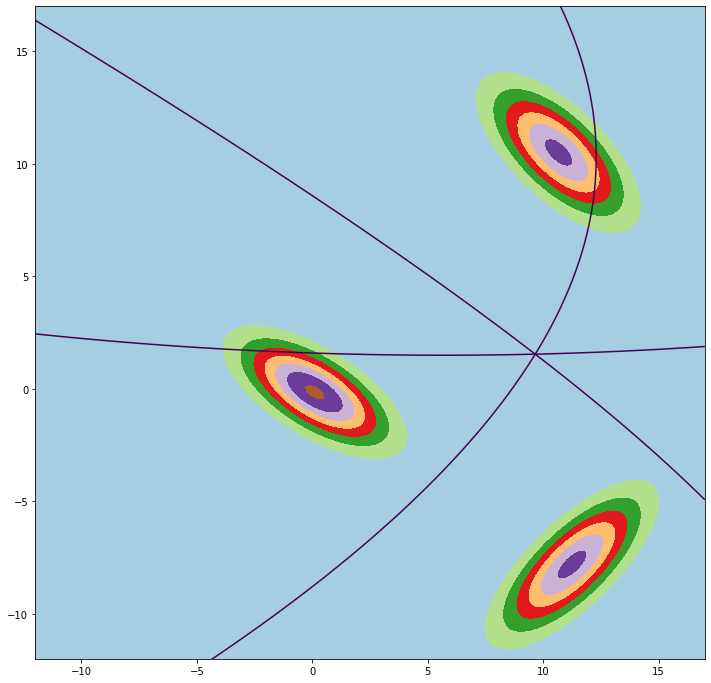

In [176]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
custom_xlim = (10,15)
custom_ylim = (15,-15)
plt.contour(X, Y, Eqn512, [0])
plt.contour(X, Y, Eqn513, [0])
plt.contour(X, Y, Eqn523, [0])

#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()

In [150]:
idx = np.argwhere(np.diff(np.sign(Eqn512 - Eqn513))).flatten()
idx

array([109,  94, 109, 170, 110,  74, 110, 190, 111,  60, 112,  47, 113,
        37, 114,  27, 115,  18, 116,  10, 117,   3])

In [219]:
Eqn523[:,109].shape

(200,)

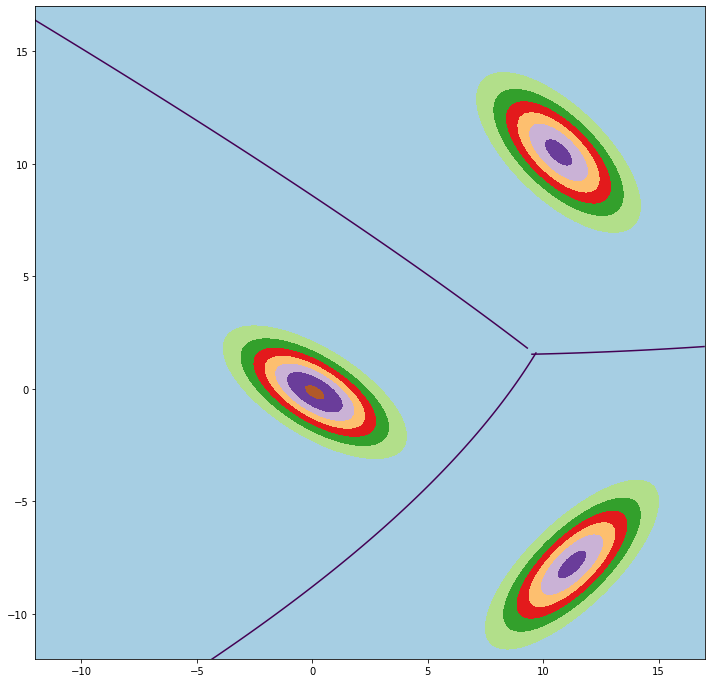

In [200]:
fig = plt.figure(figsize=(12,12))
#ax = fig.gca(projection='3d')
plt.contourf(X, Y, Z,cmap=plt.cm.Paired)
plt.contour(X[110:], Y[110:], Eqn512[110:], [0])
plt.contour(X[:110], Y[:110], Eqn513[:110], [0])
plt.contour(X[:,155:], Y[:,155:], Eqn523[:,155:], [0])
#plt.contourf(X,Y,Eqn12)
plt.axis([-12, 17, -12, 17])

plt.show()